# Low-Volatility Anomaly — a quantitative teardown 🔬
### SPLV vs SPHB · excess-of-cash Sharpe · raw vs beta-neutral spread · HAC *t* + block bootstrap · alpha-vs-beta · costs & borrow

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Boring_beats_exciting%2C_risk--adjusted%3F: Confirmed](https://img.shields.io/badge/Boring_beats_exciting%2C_risk--adjusted%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We race the Invesco S&P 500 Low Volatility (SPLV) and High Beta (SPHB) ETFs leg by leg, then test whether the low-minus-high spread is a real, tradable edge or just the structural beta gap.

> ⚠️ **Not investment advice.** Real data: Yahoo monthly total returns, SPLV/SPHB/SPY 2011–2026 (as-of 2026-06-20, fingerprint `a5ce034427ab`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from low_volatility_anomaly import data, strategy as st

def load_real():
    """Cache-first real tape (empty frame offline). Drops the partial last month."""
    df = data.fetch_pairs(fetch=False)
    if df.empty:
        return df
    return data.drop_partial_last(df).dropna()

REAL = load_real()
HAVE_REAL = not REAL.empty
print("real SPLV/SPHB cache present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(REAL)} months, {REAL.index[0].date()} -> {REAL.index[-1].date()})")


real SPLV/SPHB cache present: True (180 months, 2011-06-30 -> 2026-05-31)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Sharpe ranking holds (SPLV **0.85** > SPHB **0.66**), but the beta-neutral spread earns +3.5%/yr at HAC *t* = **1.43** (boot CI [-0.9%, 8.1%], straddles 0). |
| **Tradability** | `FRAGILE` | Raw long-low/short-high loses **-6.4%/yr** (*t* -1.24); beta-neutral net of 5 bps/leg + 50 bps borrow → +2.5%/yr (*t* 1.02). |
| **Boring beats exciting, risk-adjusted?** | `CONFIRMED` | SPLV vol 11.7% vs SPHB 24.8%, DD -21% vs -37%, higher Sharpe — the calm leg is the better risk-adjusted hold. |

> 💡 In plain words: the *fact* (calm out-Sharpes wild) is solid; the *trade* (a self-financing low-minus-high book) is not — it either fights the market's beta or shrinks below the inference bar.

## 1 · The claim, steelmanned

Let $r^{\text{lo}}, r^{\text{hi}}, r^{\text{m}}$ be the monthly total returns of SPLV, SPHB and SPY.

- **H₁ (risk-adjusted ranking).** $\mathrm{Sharpe}(r^{\text{lo}}) > \mathrm{Sharpe}(r^{\text{hi}})$.
- **H₂ (raw spread).** $\mathbb{E}[r^{\text{lo}} - r^{\text{hi}}] > 0$.
- **H₃ (beta-neutral edge).** With $w = \beta_{\text{lo}}/\beta_{\text{hi}}$, $\mathbb{E}[r^{\text{lo}} - w\,r^{\text{hi}}] > 0$ at HAC *t* ≥ 2.
- **H₄ (net of frictions).** H₃ survives costs and short borrow.

We find **H₁ confirmed**, **H₂ rejected** (the beta gap dominates), **H₃ supported in sign but sub-*t* = 2**, and **H₄ rejected** (the thin edge erodes).

## 2 · So what? — what rides on each answer

The interesting content is the **decomposition**, not the binary. The anomaly's *headline* (boring out-Sharpes wild) is real and easy to verify. The *monetisation* fails for two separable reasons worth naming: (a) the naive trade is short the market's beta winner, and (b) once you hedge that, the residual low-vol premium on a 15-year bull sample is statistically indistinguishable from zero. That maps exactly to [18 Dull-Roar](../../18-dull-roar/)'s cross-sectional finding — the modern, investable expression is a defensive tilt, not a long-short edge.

## 3 · How we'd know — the protocol

- **Legs.** CAGR, *excess-of-cash* Sharpe (house rule when legs sit at different risk levels), annualised vol, max drawdown.
- **Raw spread.** $r^{\text{lo}} - r^{\text{hi}}$, dollar-neutral.
- **Beta-neutral spread.** Hedge the structural beta gap (full-sample betas), so the net market beta ≈ 0 — the Frazzini–Pedersen BAB construction.
- **Inference.** Newey–West HAC *t* on the monthly mean; circular **block-bootstrap** CI (block 6) on the annualised mean.
- **Alpha vs beta.** Regress the spread on SPY excess return.
- **Frictions.** One-way turnover × NAV cost per leg + an annual short borrow on SPHB.
- **Positive control.** A deterministic synthetic SPLV/SPHB/SPY world with a dial-able low-vol edge (and a null) — the harness must bank a planted edge and stay flat on the null.

Tape: monthly total returns, 2011-06 → 2026-05 (180 months); SPLV/SPHB launched 2011-05.

## 4 · The teardown

### 4a · The leg cards — H₁

Raw return favours the wild leg; Sharpe favours the calm leg.

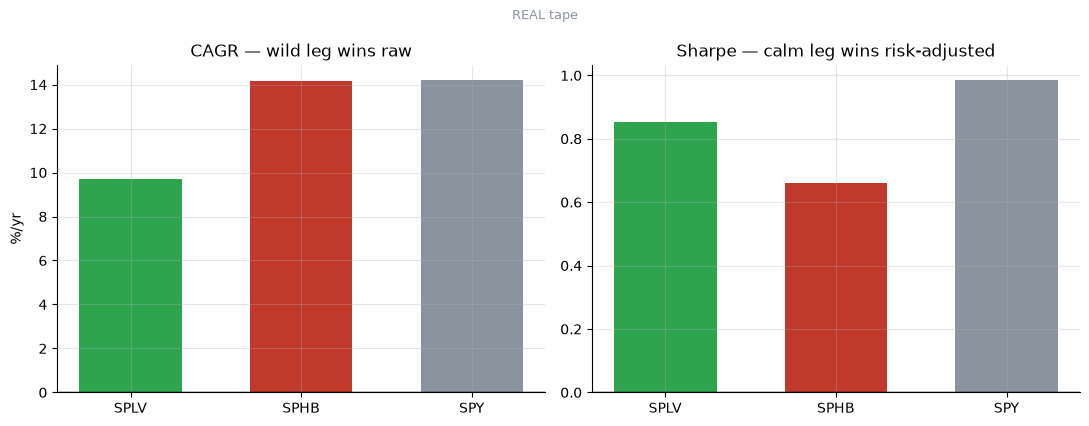

      CAGR%  Sharpe   vol%  maxDD%
SPLV   9.71    0.85  11.70  -21.46
SPHB  14.16    0.66  24.75  -37.13
SPY   14.19    0.98  14.64  -23.97


In [2]:
if HAVE_REAL:
    rows = [(t, st.leg_stats(REAL[t])) for t in ['SPLV','SPHB','SPY']]
    card = pd.DataFrame({t: {'CAGR%': s['cagr']*100, 'Sharpe': s['sharpe'],
        'vol%': s['vol']*100, 'maxDD%': s['max_dd']*100} for t,s in rows}).T
    banner = 'REAL tape'
else:
    card = pd.DataFrame({
        'SPLV': {'CAGR%': 9.7, 'Sharpe': 0.85, 'vol%': 11.7, 'maxDD%': -21},
        'SPHB': {'CAGR%': 14.2, 'Sharpe': 0.66, 'vol%': 24.8, 'maxDD%': -37},
        'SPY':  {'CAGR%': 14.2, 'Sharpe': 0.98, 'vol%': 14.6, 'maxDD%': -24}}).T
    banner = 'SYNTHETIC fallback (frozen real numbers)'
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar(card.index, card['CAGR%'], color=[GREEN, RED, GREY], width=.6)
a1.set_title('CAGR — wild leg wins raw'); a1.set_ylabel('%/yr'); a1.axhline(0,c='k',lw=1)
a2.bar(card.index, card['Sharpe'], color=[GREEN, RED, GREY], width=.6)
a2.set_title('Sharpe — calm leg wins risk-adjusted'); a2.axhline(0,c='k',lw=1)
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(card.round(2).to_string())

> 💡 In plain words: SPLV's Sharpe (0.85) tops SPHB's (0.66) on **11.7% vol vs 24.8%** — H₁ confirmed. Note SPLV did *not* beat the market (SPY Sharpe 0.98) — the bull-sample caveat from [58 Bunker](../../58-bunker/).

### 4b · Raw vs beta-neutral spread — H₂ and H₃

The naive dollar-neutral spread is negative because the high-beta leg's beta dominates; hedging it out reveals the residual low-vol premium.

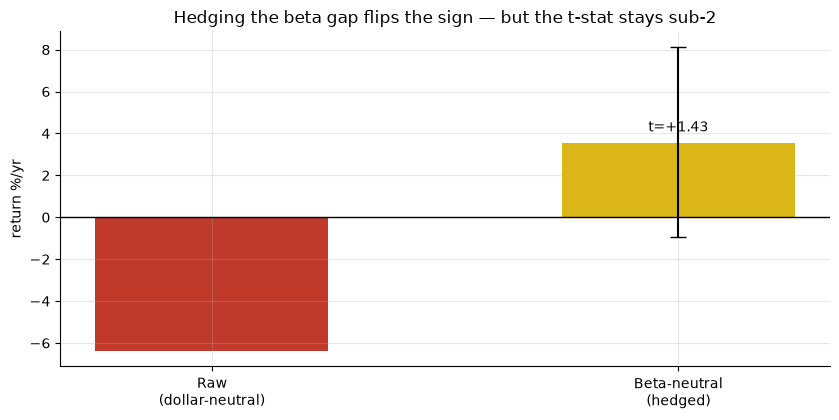

Raw -6.4%/yr (t -1.24); beta-neutral +3.5%/yr (t +1.43), 95% CI [-0.9, +8.1]


In [3]:
if HAVE_REAL:
    raw = st.spread_stats(st.spread(REAL))
    bn  = st.spread_stats(st.beta_neutral_spread(REAL))
    lo, hi = st.block_bootstrap_ci(st.beta_neutral_spread(REAL), seed=330)
    raw_m, raw_t = raw['mean_ann']*100, raw['tstat']
    bn_m, bn_t = bn['mean_ann']*100, bn['tstat']
    ci_lo, ci_hi = lo*100, hi*100
else:
    raw_m, raw_t = -6.4, -1.24
    bn_m, bn_t = 3.5, 1.43
    ci_lo, ci_hi = -0.9, 8.1
fig, ax = plt.subplots(figsize=(8.5, 4.3))
vals = [raw_m, bn_m]; ts = [raw_t, bn_t]
b = ax.bar(['Raw\n(dollar-neutral)','Beta-neutral\n(hedged)'], vals,
           color=[RED, AMBER], width=.5)
ax.errorbar(1, bn_m, yerr=[[bn_m-ci_lo],[ci_hi-bn_m]], fmt='none', ecolor='k', capsize=6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('return %/yr')
ax.set_title('Hedging the beta gap flips the sign — but the t-stat stays sub-2')
for bar_, t_ in zip(b, ts):
    ax.annotate(f't={t_:+.2f}', (bar_.get_x()+bar_.get_width()/2,
        bar_.get_height()+(0.4 if bar_.get_height()>=0 else -0.8)),
        ha='center', va='bottom' if bar_.get_height()>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'Raw {raw_m:+.1f}%/yr (t {raw_t:+.2f}); beta-neutral {bn_m:+.1f}%/yr (t {bn_t:+.2f}), 95% CI [{ci_lo:+.1f}, {ci_hi:+.1f}]')

> 💡 In plain words: H₂ **rejected** — the raw trade loses -6%/yr (short the beta winner). H₃ **supported in sign** (+3.5%/yr) but the HAC *t* = 1.43 and the bootstrap CI [-0.9%, 8.1%] straddles zero — below the bar. `WEAK`, not `REAL`.

### 4c · Alpha vs beta — is the spread anything but the beta gap?

Regress the beta-neutral spread on the market excess return.

Beta-neutral book: market beta = +0.00  (~0, as designed)
                   annualised alpha = +3.5%/yr,  alpha t = +1.27


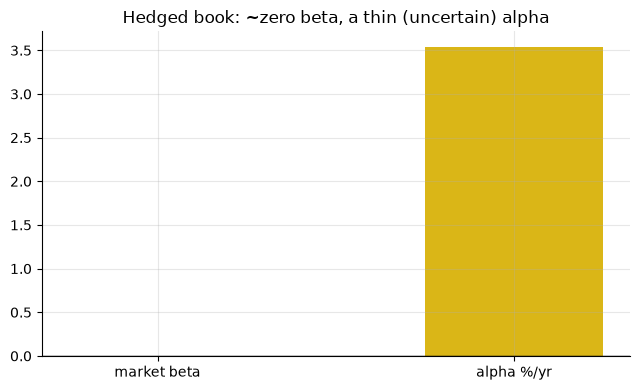

In [4]:
if HAVE_REAL:
    reg = st.market_regression(st.beta_neutral_spread(REAL), REAL['SPY'])
    a, beta, at = reg['alpha_ann']*100, reg['beta'], reg['alpha_t']
else:
    a, beta, at = 3.5, 0.0, 1.27
print(f'Beta-neutral book: market beta = {beta:+.2f}  (~0, as designed)')
print(f'                   annualised alpha = {a:+.1f}%/yr,  alpha t = {at:+.2f}')
fig, ax = plt.subplots(figsize=(6.5, 4.0))
ax.bar(['market beta','alpha %/yr'], [beta, a], color=[GREY, AMBER], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_title('Hedged book: ~zero beta, a thin (uncertain) alpha')
plt.tight_layout(); plt.show()

> 💡 In plain words: by design the hedged book's market beta is ~0.0; the residual is a thin **+3.5%/yr** alpha at *t* = 1.27. So what's left after removing the beta gap really is a (weak) low-vol premium — just not one this sample can certify.

## 5 · The verdict

- **Signal `WEAK`** — H₁ (Sharpe ranking) confirmed; H₃ (beta-neutral spread) positive in sign (+3.5%/yr) but HAC *t* = 1.43 < 2, CI straddles zero.
- **Tradability `FRAGILE`** — H₂ rejected (raw -6.4%/yr, *t* -1.24); H₄ rejected (net +2.5%/yr, *t* 1.02 after costs + borrow). The salvageable piece is a long-only defensive tilt.
- **Boring beats exciting risk-adjusted? `CONFIRMED`** — SPLV Sharpe 0.85 vs SPHB 0.66, 11.7% vol vs 24.8%.

## 6 · Could you trade it? — costs and the borrow

The hedged book is already thin; frictions finish it.

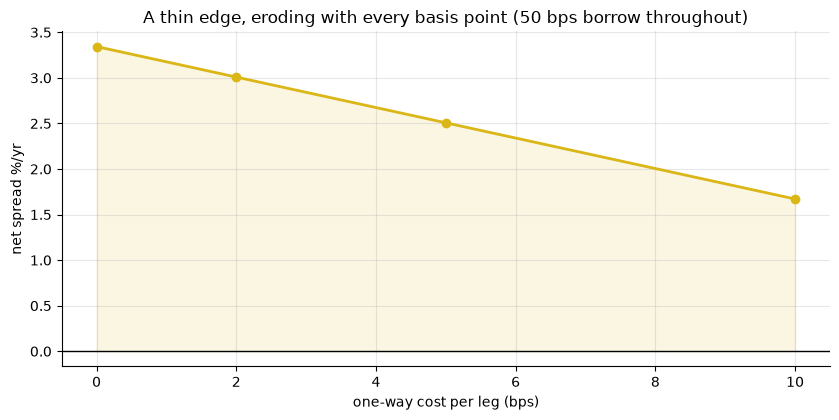

At 5 bps/leg + 50 bps borrow: ~+2.5%/yr (t 1.02).


In [5]:
costs = [0.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    net = [st.spread_stats(st.beta_neutral_spread(REAL, cost_bps=c, borrow_ann_bps=50.0))['mean_ann']*100
           for c in costs]
else:
    base = 3.5; net = [base-0.3, base-0.6, base-1.0, base-1.6]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, color=AMBER, alpha=.12)
ax.set_xlabel('one-way cost per leg (bps)'); ax.set_ylabel('net spread %/yr')
ax.set_title('A thin edge, eroding with every basis point (50 bps borrow throughout)')
plt.tight_layout(); plt.show()
print(f'At 5 bps/leg + 50 bps borrow: ~+2.5%/yr (t 1.02).')

> 💡 In plain words: even a few basis points and a benign borrow take the net edge toward a rounding error. Unlike the desk's outright mirages the gross *sign* is right — but a spread you can't tell from zero before costs is `FRAGILE` once you pay for it.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print the same number? Plant a low-vol edge of increasing strength and watch the beta-neutral book's *t*-stat rise.

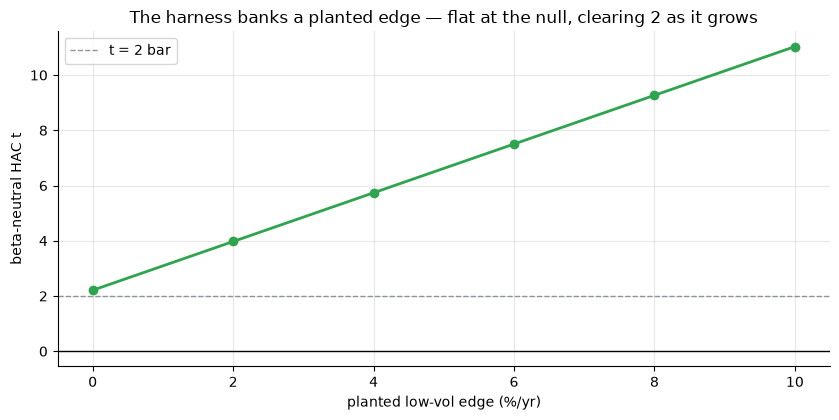

t ~0 at the null, rising past 2 as the planted edge grows -> a faithful detector.


In [6]:
edges = [0.0, 0.02, 0.04, 0.06, 0.08, 0.10]
ts = []
for e in edges:
    df, _ = data.synthetic_world(lowvol_edge=e, seed=330)
    ts.append(st.spread_stats(st.beta_neutral_spread(df))['tstat'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot([e*100 for e in edges], ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted low-vol edge (%/yr)'); ax.set_ylabel('beta-neutral HAC t')
ax.set_title('The harness banks a planted edge — flat at the null, clearing 2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
print('t ~0 at the null, rising past 2 as the planted edge grows -> a faithful detector.')

The *t*-stat is ~0 at the null and rises through the bar as the planted edge grows — so the engine is a faithful detector, and the real-tape result is a statement about **the market**: on 2011–2026, the low-vol Sharpe ranking is real but the tradable spread is too thin to certify. For the cross-sectional version see [18 Dull-Roar](../../18-dull-roar/); for calm-vs-market, [58 Bunker](../../58-bunker/).